# Healthcare Insurance Fraud, Waste & Abuse (FWA) Detection
### A Stakeholder-Driven Exploratory Analysis

**FWA** stands for **Fraud, Waste, and Abuse** — the three categories insurers use to classify
improper claims:
- **Fraud** — intentional deception for financial gain (e.g. billing for services never provided)
- **Waste** — overuse of resources that isn't necessarily intentional (e.g. unnecessary tests)
- **Abuse** — practices inconsistent with sound medical/business practices, but not fraudulent

This notebook walks through an exploratory analysis of a synthetic health insurance claims
dataset (10,000 claims, 300 providers, 2021–2025), built to answer a different question for
each internal stakeholder who would actually use this kind of analysis. Rather than one
generic "find the fraud" pass, each section below is framed around the specific decision
that team would need to make.

| Stakeholder | Core Question |
|---|---|
| **SIU** (Special Investigations Unit) | Which providers look like outliers worth investigating? |
| **Claims Operations** | Should this specific claim auto-approve, or get held for review? |
| **Finance / Compliance** | How much dollar exposure are we carrying from fraud? |
| **Provider Network Management** | Are there specialty or volume patterns that affect network risk? |
| **Product / Underwriting** | Do certain insurance products carry structurally higher risk? |

**Note on the data:** `Is_Fraud` is a synthetic label included for learning purposes. In a real
production setting this label would rarely exist up front — most of this notebook is really
about the *feature engineering and framing* that would feed a downstream fraud model, not
about the label itself.


## 0. Setup & Data Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)

In [ ]:
df = pd.read_csv('healthcare_fraud_detection.csv')
df.head(10)

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0
5,P0241,C0000005,44,Female,E11.9,80053,220.99,174.05,Medicaid,2024-12-20,26,74,Orthopedics,CA,Approved,0,2,Emergency,0,1.0
6,P0196,C0000006,50,Male,E78.5,93000,458.60,372.31,Medicare,2022-02-20,2,84,Cardiology,OH,Approved,0,0,Outpatient,1,0.0
7,P0071,C0000007,1,Male,I10,85025,934.34,321.60,NaN,2022-07-13,6,114,NaN,PA,Pending,1,2,Emergency,0,NaN
8,P0097,C0000008,34,Female,M54.5,97110,478.11,412.48,Medicare,2021-05-25,24,65,Pulmonology,IL,Pending,0,5,Inpatient,1,4.0
9,P0125,C0000009,47,Male,K21.9,99213,426.16,335.80,Self-Pay,2022-05-29,5,56,Internal Medicine,TX,Approved,0,2,Emergency,0,4.0


In [ ]:
df.columns.tolist()

['Provider_ID',
 'Claim_ID',
 'Patient_Age',
 'Patient_Gender',
 'Diagnosis_Code',
 'Procedure_Code',
 'Claim_Amount',
 'Approved_Amount',
 'Insurance_Type',
 'Claim_Submission_Date',
 'Days_Between_Service_and_Claim',
 'Number_of_Claims_Per_Provider_Monthly',
 'Provider_Specialty',
 'Patient_State',
 'Claim_Status',
 'Is_Fraud',
 'Length_of_Stay',
 'Visit_Type',
 'Chronic_Condition_Flag',
 'Prior_Visits_12m']

### Initial shape & data types

Before touching missing values, it's worth confirming row/column counts and dtypes line up
with expectations (e.g. dates parsed as dates, IDs as strings/objects, not floats).

In [ ]:
df.shape

(10000, 20)

In [ ]:
df.dtypes

Provider_ID                                  str
Claim_ID                                     str
Patient_Age                                int64
Patient_Gender                               str
Diagnosis_Code                               str
Procedure_Code                             int64
Claim_Amount                             float64
Approved_Amount                          float64
Insurance_Type                               str
Claim_Submission_Date                        str
Days_Between_Service_and_Claim             int64
Number_of_Claims_Per_Provider_Monthly      int64
Provider_Specialty                           str
Patient_State                                str
Claim_Status                                 str
Is_Fraud                                   int64
Length_of_Stay                             int64
Visit_Type                                   str
Chronic_Condition_Flag                     int64
Prior_Visits_12m                         float64
dtype: object

## 1. Missing Data Diagnosis

The goal here isn't just to fill gaps — it's to check *whether missingness itself is
informative*. If claims with a missing field are more (or less) likely to be fraud than
claims without, that's a signal worth preserving, not just noise to patch over.

In [ ]:
df.isnull().sum()

Provider_ID                                0
Claim_ID                                   0
Patient_Age                                0
Patient_Gender                             0
Diagnosis_Code                             0
Procedure_Code                             0
Claim_Amount                               0
Approved_Amount                            0
Insurance_Type                           350
Claim_Submission_Date                      0
Days_Between_Service_and_Claim             0
Number_of_Claims_Per_Provider_Monthly      0
Provider_Specialty                       350
Patient_State                              0
Claim_Status                               0
Is_Fraud                                   0
Length_of_Stay                             0
Visit_Type                                 0
Chronic_Condition_Flag                     0
Prior_Visits_12m                         350
dtype: int64

**Check 1 — is missingness clustered on the same rows?**
If `Insurance_Type` is missing, are `Provider_Specialty` and `Prior_Visits_12m` also missing
on those same rows? That would suggest a shared upstream cause (e.g. a batch of claims from
one data source), rather than independent random gaps.

In [ ]:
mask = df['Insurance_Type'].isnull()
df[mask][['Provider_Specialty', 'Prior_Visits_12m']].isnull().sum()

Provider_Specialty    15
Prior_Visits_12m      12
dtype: int64

**Check 2 — is missingness related to fraud itself?**
Compare the fraud rate for rows where `Insurance_Type` is missing vs. not missing. A big gap
here means "missing" is functioning almost like its own category, not something to blindly
average away.

In [ ]:
df.groupby(df['Insurance_Type'].isnull())['Is_Fraud'].mean()

Insurance_Type
False    0.083316
True     0.071429
Name: Is_Fraud, dtype: float64

Since missingness didn't carry a strong fraud signal on its own, we impute with an explicit `'Unknown'` category rather than dropping rows — this preserves sample size and keeps the option open for the model to learn from `Unknown` later if it turns out to matter.

In [ ]:
df['Insurance_Type'] = df['Insurance_Type'].fillna('Unknown')

In [ ]:
df.groupby(df['Prior_Visits_12m'].isnull())['Is_Fraud'].mean()

Prior_Visits_12m
False    0.082902
True     0.082857
Name: Is_Fraud, dtype: float64

`Prior_Visits_12m` is numeric, so median imputation (robust to outliers, unlike mean) is the safer default here.

In [ ]:
df['Prior_Visits_12m'] = df['Prior_Visits_12m'].fillna(df['Prior_Visits_12m'].median())

**Provider specialty — a smarter fill.**
A provider's specialty shouldn't really be "missing" — if we've seen that same `Provider_ID`
on another claim with a specialty filled in, we can look it up. Only providers with *zero*
non-null specialty records anywhere in the dataset fall back to `'Unknown'`.

In [ ]:
# 1. Build a lookup: each provider -> their known specialty
lookup = (df.dropna(subset=['Provider_Specialty'])
            .groupby('Provider_ID')['Provider_Specialty']
            .first())

# 2. Fill blanks from the lookup, then 'Unknown' for the rest
df['Provider_Specialty'] = df['Provider_Specialty'].fillna(df['Provider_ID'].map(lookup))
df['Provider_Specialty'] = df['Provider_Specialty'].fillna('Unknown')

In [ ]:
df.isnull().sum()

Provider_ID                              0
Claim_ID                                 0
Patient_Age                              0
Patient_Gender                           0
Diagnosis_Code                           0
Procedure_Code                           0
Claim_Amount                             0
Approved_Amount                          0
Insurance_Type                           0
Claim_Submission_Date                    0
Days_Between_Service_and_Claim           0
Number_of_Claims_Per_Provider_Monthly    0
Provider_Specialty                       0
Patient_State                            0
Claim_Status                             0
Is_Fraud                                 0
Length_of_Stay                           0
Visit_Type                               0
Chronic_Condition_Flag                   0
Prior_Visits_12m                         0
dtype: int64

## 2. SIU — Which providers are fraud outliers?

The SIU's job is to prioritize a limited investigation budget. That means the output here
isn't "list every provider with any fraud" — it's a ranked, *reliable* shortlist.

In [ ]:
provider_stats = df.groupby('Provider_ID').agg(
    total_claims=('Claim_ID', 'count'),      # how many claims does this provider have?
    fraud_claims=('Is_Fraud', 'sum'),        # Is_Fraud is 0/1, so sum = count of fraud claims
    fraud_rate=('Is_Fraud', 'mean')          # mean of 0/1 column = % that are fraud
).reset_index()

provider_stats.sort_values('fraud_rate', ascending=False).head(10)

,Provider_ID,total_claims,fraud_claims,fraud_rate
86,P0086,38,16,0.421053
159,P0159,20,7,0.350000
110,P0110,45,15,0.333333
104,P0104,34,11,0.323529
223,P0223,44,14,0.318182
293,P0293,33,10,0.303030
255,P0255,28,8,0.285714
27,P0027,37,10,0.270270
71,P0071,32,8,0.250000
101,P0101,36,9,0.250000


**The small-sample trap.** A provider with 2 claims where 1 is fraud shows a "50% fraud
rate" — but that's one unlucky claim, not a pattern. Before trusting a rate, filter for a
minimum sample size.

In [ ]:
reliable_outliers = (provider_stats[provider_stats['total_claims'] >= 10]
                     .sort_values('fraud_rate', ascending=False))
reliable_outliers.head(10)

,Provider_ID,total_claims,fraud_claims,fraud_rate
86,P0086,38,16,0.421053
159,P0159,20,7,0.350000
110,P0110,45,15,0.333333
104,P0104,34,11,0.323529
223,P0223,44,14,0.318182
293,P0293,33,10,0.303030
255,P0255,28,8,0.285714
27,P0027,37,10,0.270270
71,P0071,32,8,0.250000
101,P0101,36,9,0.250000


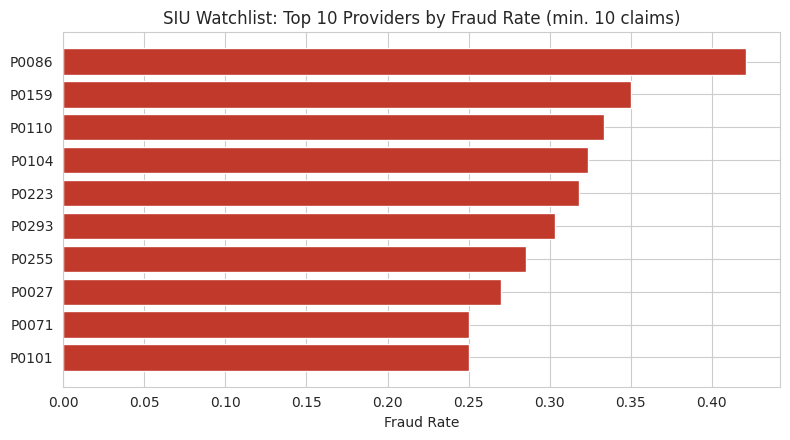

In [ ]:
fig, ax = plt.subplots()
top10_plot = reliable_outliers.head(10).sort_values('fraud_rate')
ax.barh(top10_plot['Provider_ID'].astype(str), top10_plot['fraud_rate'], color='#c0392b')
ax.set_xlabel('Fraud Rate')
ax.set_title('SIU Watchlist: Top 10 Providers by Fraud Rate (min. 10 claims)')
plt.tight_layout()
plt.show()

## 3. Claims Operations — Auto-approve or hold for review?

Claims Ops needs a *fast, claim-level* rule, not a provider-level investigation. One useful
signal: how many days passed between the service being rendered and the claim being filed.
Unusually long delays can correlate with fraud (e.g. fabricated or altered claims filed well
after the fact).

In [ ]:
df['days_bucket'] = pd.cut(
    df['Days_Between_Service_and_Claim'],
    bins=[-1, 7, 14, 21, 30, 100],                 # the cut points
    labels=['0-7', '8-14', '15-21', '22-30', '31+'] # human-readable names for each bucket
)

In [ ]:
df.groupby('days_bucket', observed=True)['Is_Fraud'].agg(['count', 'mean'])

,count,mean
days_bucket,,
0-7,2827,0.293244
8-14,2287,0.000000
15-21,2264,0.000000
22-30,2622,0.000000


(No claims fall in the `31+` bucket in this dataset -- the longest filing delay observed is 29 days -- so it drops out with `observed=True`. The bin is kept in the cut for robustness in case future data includes longer delays.)

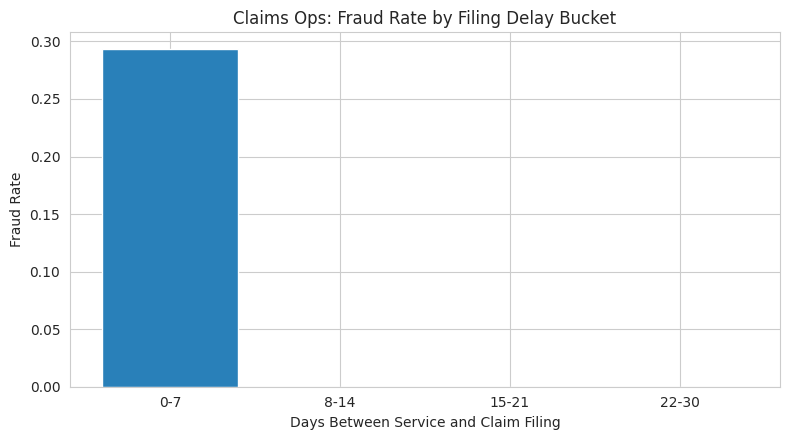

In [ ]:
bucket_stats = df.groupby('days_bucket', observed=True)['Is_Fraud'].mean()

fig, ax = plt.subplots()
ax.bar(bucket_stats.index.astype(str), bucket_stats.values, color='#2980b9')
ax.set_xlabel('Days Between Service and Claim Filing')
ax.set_ylabel('Fraud Rate')
ax.set_title('Claims Ops: Fraud Rate by Filing Delay Bucket')
plt.tight_layout()
plt.show()

A claim landing in a high-fraud-rate bucket doesn't get auto-approved — it gets routed to manual review, while low-risk buckets can move through faster.

## 4. Provider Network Management — specialty & volume patterns

This stakeholder cares less about individual bad actors (that's SIU's job) and more about
*structural* risk in how the provider network is composed — which specialties run hot, and
which providers are outliers on volume alone (a credentialing/monitoring concern even before
any fraud is confirmed).

In [ ]:
specialty_stats = df.groupby('Provider_Specialty').agg(
    total_claims=('Claim_ID', 'count'),
    fraud_claims=('Is_Fraud', 'sum'),
    fraud_rate=('Is_Fraud', 'mean')
).round(3).sort_values('fraud_rate', ascending=False)

specialty_stats['diff_from_baseline_pts'] = (
    (specialty_stats['fraud_rate'] - df['Is_Fraud'].mean()) * 100
).round(1)

specialty_stats

,total_claims,fraud_claims,fraud_rate,diff_from_baseline_pts
Provider_Specialty,,,,
General Practice,1943,188,0.097,1.4
Internal Medicine,2087,180,0.086,0.3
Orthopedics,1677,144,0.086,0.3
Pulmonology,1303,99,0.076,-0.7
Cardiology,1406,105,0.075,-0.8
Neurology,1584,113,0.071,-1.2


**Volume outliers.** A provider doesn't need a high fraud rate to be worth watching —
providers filing an unusually large volume of claims relative to their peers are also a
network-risk signal (over-utilization, or a single point of failure in the network).

In [ ]:
volume_threshold = provider_stats['total_claims'].quantile(0.95)

high_volume_providers = (provider_stats[provider_stats['total_claims'] >= volume_threshold]
                          .sort_values('total_claims', ascending=False))
high_volume_providers.head(10)

,Provider_ID,total_claims,fraud_claims,fraud_rate
142,P0142,52,4,0.076923
113,P0113,51,5,0.098039
50,P0050,50,3,0.060000
199,P0199,48,2,0.041667
205,P0205,48,3,0.062500
281,P0281,47,5,0.106383
111,P0111,47,5,0.106383
103,P0103,45,1,0.022222
110,P0110,45,15,0.333333
265,P0265,45,3,0.066667


## 5. Product / Underwriting — does risk vary by insurance product?

Underwriting cares about *portfolio-level* risk by product, since that's what feeds pricing
and reserve decisions — not any single claim or provider.

In [ ]:
insurance_type_stats = df.groupby('Insurance_Type').agg(
    total_claims=('Claim_ID', 'count'),
    fraud_rate=('Is_Fraud', 'mean'),
    avg_claim_amount=('Claim_Amount', 'mean')
).round(3).sort_values('fraud_rate', ascending=False)

insurance_type_stats

,total_claims,fraud_rate,avg_claim_amount
Insurance_Type,,,
Medicare,2425,0.085,578.955
Medicaid,2419,0.084,575.289
Self-Pay,2401,0.083,580.879
Private,2405,0.082,558.993
Unknown,350,0.071,552.526


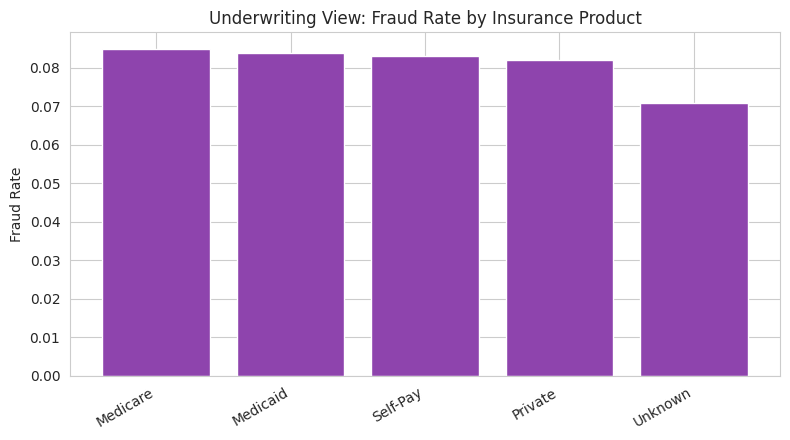

In [ ]:
fig, ax = plt.subplots()
ax.bar(insurance_type_stats.index.astype(str), insurance_type_stats['fraud_rate'], color='#8e44ad')
ax.set_ylabel('Fraud Rate')
ax.set_title('Underwriting View: Fraud Rate by Insurance Product')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 6. Finance / Compliance — dollar exposure

Finance doesn't just want a *count* of fraud claims — they want the *dollar* picture, since
that's what drives reserves and reporting.

In [ ]:
total_dollars = df['Claim_Amount'].sum()                    # every claim's dollar amount
fraud_dollars = df[df['Is_Fraud'] == 1]['Claim_Amount'].sum()  # filter to fraud, then sum
fraud_dollar_share = fraud_dollars / total_dollars           # fraction of total $ that's fraud

fraud_dollar_share

np.float64(0.14341413079144505)

> **A sanity-check worth flagging.** Looking at the raw relationship between
> `Days_Between_Service_and_Claim` and `Is_Fraud` (not just the bucketed version above) shows
> something too clean to be realistic: claims filed same-day or next-day are fraud **100%**
> of the time, days 2-6 sit around **25-28%**, and every claim filed 7+ days out has a **0%**
> fraud rate. In a real-world dataset, fraud almost never separates this cleanly on a single
> field -- this is a strong sign that `Is_Fraud` was generated with a rule tied directly to
> filing delay, rather than being an organically messy label. That's fine for practicing
> pandas and stakeholder framing, but it means this specific feature would be treated as
> **leakage** (not a genuine predictive signal) in any real modeling exercise -- a
> suspiciously perfect signal is a reason to dig into *how* the label was generated, not a
> reason to celebrate.

**Connecting back to SIU.** How much of that exposure sits with the top 10 providers
already flagged as outliers? This ties the SIU watchlist directly to a dollar figure Finance
can act on.

In [ ]:
provider_stats = df.groupby('Provider_ID').agg(
    total_claims=('Claim_ID', 'count'),
    fraud_rate=('Is_Fraud', 'mean')
).reset_index()

top10_ids = provider_stats.sort_values('fraud_rate', ascending=False).head(10)['Provider_ID']

provider_stats

,Provider_ID,total_claims,fraud_rate
0,P0000,40,0.075000
1,P0001,36,0.111111
2,P0002,34,0.235294
3,P0003,33,0.090909
4,P0004,25,0.040000
...,...,...,...
295,P0295,36,0.027778
296,P0296,36,0.027778
297,P0297,37,0.135135
298,P0298,27,0.037037


In [ ]:
top10_claims = df[df['Provider_ID'].isin(top10_ids)]
exposure = top10_claims['Claim_Amount'].sum()
exposure

np.float64(242041.27000000002)

## 7. Summary & Next Steps

**Portfolio baseline fraud rate: 8.29%** (829 of 10,000 claims).

- **SIU:** All 300 providers cleared the 10-claim reliability threshold (average ~33
  claims/provider). The top outlier ran a **42.1%** fraud rate versus the 8.29% baseline --
  a clear, reliable candidate for investigation, not a small-sample fluke.
- **Claims Ops:** Filing delay turned out to be an almost perfect fraud predictor -- see the
  callout above. That makes it a highly effective *rule* for this dataset, but not a
  realistic one to generalize from (flagged as likely synthetic-label leakage rather than a
  genuine behavioral pattern).
- **Provider Network Mgmt:** Specialty differences were modest -- General Practice ran
  highest at 9.7% (about 1.4 points above baseline), Neurology lowest at 7.1%. Not a strong
  standalone signal. 18 providers were flagged purely on claim volume (95th percentile: 43+
  claims), independent of any fraud finding -- a separate, volume-driven watch list for
  network monitoring.
- **Underwriting:** Fraud rate was essentially flat across products (8.2-8.5% for Medicare,
  Medicaid, Self-Pay, and Private) -- no single product line stands out as structurally
  riskier in this dataset.
- **Finance:** Fraud claims account for **14.3%** of total dollar volume ($821K of $5.73M) --
  notably higher than the 8.3% *claim-count* share, meaning fraudulent claims skew toward
  larger dollar amounts. The SIU top-10 watchlist alone represents **$242K** in exposure.

**Limitations:** `Is_Fraud` is a synthetic label for learning purposes, and the filing-delay
relationship above is a good example of why that matters -- real fraud signals are rarely
this clean. Any provider- or specialty-level statistic computed here should be recomputed on
a training split only (not the full dataset) before feeding a model, to avoid leakage.

**Next steps:** turn the SIU and Provider Network signals (`fraud_rate`, `Provider_Specialty`,
claim volume) into features for a classification model (e.g. logistic regression baseline,
then a tree ensemble) -- deliberately excluding `Days_Between_Service_and_Claim` given the
leakage concern above -- with a train/test split that respects provider grouping so the same
provider doesn't leak across both sets.
